# DistilBERT Fine-Tuning — Notebook 2: Evaluation & Inference

**No training happens here. No GPU required.**

This notebook loads the model and test split saved by Notebook 1 and runs:
- Training curves
- Final test set evaluation
- Error analysis
- Inference utilities (single article + batch)
- Probability calibration check

**Prerequisites:** the `distilbert_finetuned/` folder must be in the same
directory as this notebook. It should contain:
```
distilbert_finetuned/
    model.safetensors
    config.json
    tokenizer.json
    tokenizer_config.json
    test_texts.npy        ← saved by Notebook 1
    test_labels.npy       ← saved by Notebook 1
    training_history.npy  ← saved by Notebook 1
```

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1. Imports & Configuration

In [2]:
# Uncomment if running on a fresh machine (not needed on Colab)
# !pip install transformers scikit-learn torch tqdm matplotlib seaborn

import os
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import (
    DistilBertTokenizerFast,
    DistilBertForSequenceClassification,
)
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
)
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
import warnings
warnings.filterwarnings('ignore')

# ── Config ────────────────────────────────────────────────────────────────────
SAVE_DIR   = '/content/drive/MyDrive/Colab Notebooks/Thesis Notebooks and Data/distilbert_finetuned'   # folder produced by Notebook 1
MAX_LEN    = 256                        # must match Notebook 1
BATCH_SIZE = 32                         # inference only, can be larger than training

# ── Device ────────────────────────────────────────────────────────────────────
# GPU is nice but not required — inference on CPU is fast enough
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

# ── Verify the folder exists and has expected files ───────────────────────────
required = ['model.safetensors', 'config.json', 'tokenizer.json',
            'tokenizer_config.json', 'test_texts.npy',
            'test_labels.npy', 'training_history.npy']
found    = os.listdir(SAVE_DIR)
missing  = [f for f in required if f not in found]

if missing:
    print(f"\n⚠️  Missing files in {SAVE_DIR}/: {missing}")
    print("Make sure you ran Notebook 1 and placed the folder correctly.")
else:
    print(f"\n✅ All required files found in {SAVE_DIR}/")

Device: cuda

✅ All required files found in /content/drive/MyDrive/Colab Notebooks/Thesis Notebooks and Data/distilbert_finetuned/


## 2. Load Model, Tokenizer & Test Split

In [3]:
# Load tokenizer and model from the saved checkpoint
tokenizer        = DistilBertTokenizerFast.from_pretrained(SAVE_DIR)
distilbert_model = DistilBertForSequenceClassification.from_pretrained(SAVE_DIR)
distilbert_model = distilbert_model.to(device)
distilbert_model.eval()
print("✅ Model and tokenizer loaded")

# Load the exact test split saved by Notebook 1
# These are the same rows the model never saw during training
X_test  = np.load(os.path.join(SAVE_DIR, 'test_texts.npy'),  allow_pickle=True)
y_test  = np.load(os.path.join(SAVE_DIR, 'test_labels.npy'), allow_pickle=True)
history = np.load(os.path.join(SAVE_DIR, 'training_history.npy'), allow_pickle=True).item()

print(f"\nTest set: {len(X_test):,} articles")
print(f"  Real (0): {(y_test==0).sum():,}")
print(f"  Fake (1): {(y_test==1).sum():,}")
print(f"\nTraining history loaded: {list(history.keys())}")

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

✅ Model and tokenizer loaded

Test set: 10,815 articles
  Real (0): 5,255
  Fake (1): 5,560

Training history loaded: ['train_loss', 'val_loss', 'val_acc', 'val_f1']


## 3. Training Curves

Plotted from the history saved by Notebook 1 — no retraining needed.

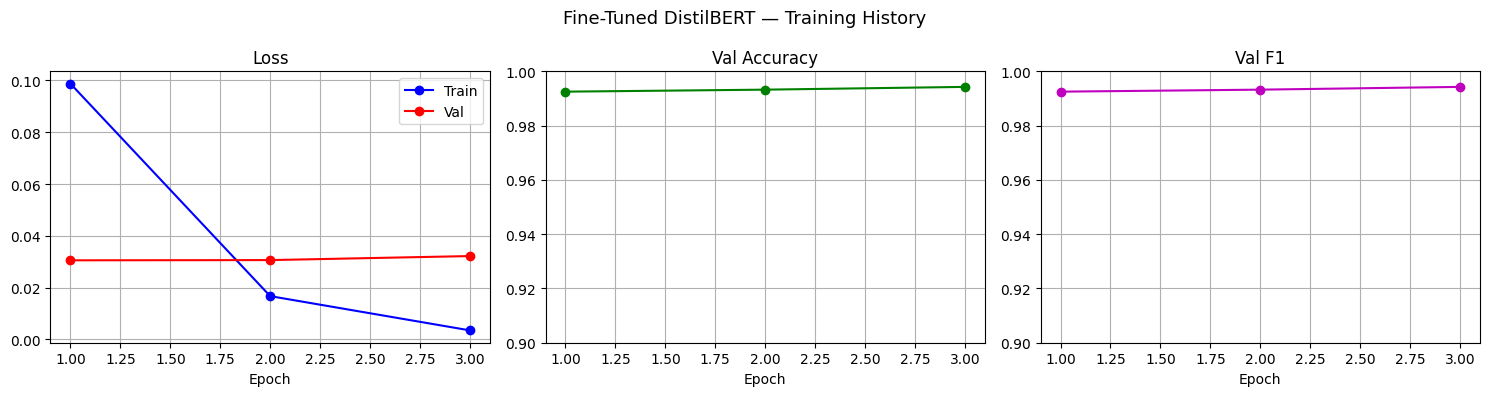

Best epoch: 3  |  Val F1: 0.9943  |  Val Acc: 0.9943


In [4]:
NUM_EPOCHS = len(history['train_loss'])
epochs     = range(1, NUM_EPOCHS + 1)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(epochs, history['train_loss'], 'b-o', label='Train')
axes[0].plot(epochs, history['val_loss'],   'r-o', label='Val')
axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch')
axes[0].legend(); axes[0].grid(True)

axes[1].plot(epochs, history['val_acc'], 'g-o')
axes[1].set_title('Val Accuracy'); axes[1].set_xlabel('Epoch')
axes[1].set_ylim([0.9, 1.0]); axes[1].grid(True)

axes[2].plot(epochs, history['val_f1'], 'm-o')
axes[2].set_title('Val F1'); axes[2].set_xlabel('Epoch')
axes[2].set_ylim([0.9, 1.0]); axes[2].grid(True)

plt.suptitle('Fine-Tuned DistilBERT — Training History', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'training_curves.png'), dpi=150)
plt.show()

best_epoch = history['val_f1'].index(max(history['val_f1'])) + 1
print(f"Best epoch: {best_epoch}  |  "
      f"Val F1: {max(history['val_f1']):.4f}  |  "
      f"Val Acc: {history['val_acc'][best_epoch-1]:.4f}")

## 4. Final Evaluation on Test Set

This is the true unbiased measure — the model has never seen these articles
in any form during training or validation.

In [5]:
class FakeNewsDataset(Dataset):
    """Same dataset class as Notebook 1 — needed to build the test loader."""
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts     = texts
        self.labels    = labels
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt',
        )
        return {
            'input_ids':      encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'label':          torch.tensor(self.labels[idx], dtype=torch.long),
        }


test_dataset = FakeNewsDataset(X_test, y_test, tokenizer, MAX_LEN)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
print(f"Test batches: {len(test_loader):,}")

Test batches: 338


In [6]:
all_preds, all_labels, all_probs, total_loss = [], [], [], 0.0

distilbert_model.eval()
with torch.no_grad():
    for batch in tqdm(test_loader, desc='Test evaluation'):
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['label'].to(device)

        outputs = distilbert_model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels,
        )
        total_loss += outputs.loss.item()

        probs = torch.softmax(outputs.logits, dim=-1).cpu().numpy()
        preds = probs.argmax(axis=-1)

        all_probs.extend(probs)
        all_preds.extend(preds)
        all_labels.extend(labels.cpu().numpy())

all_probs  = np.array(all_probs)   # shape (n, 2)
all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

test_loss = total_loss / len(test_loader)
test_acc  = accuracy_score(all_labels, all_preds)
test_f1   = f1_score(all_labels, all_preds, average='weighted')

print("\n" + "=" * 60)
print("TEST SET RESULTS")
print("=" * 60)
print(f"Loss:     {test_loss:.4f}")
print(f"Accuracy: {test_acc:.4f}")
print(f"F1:       {test_f1:.4f}")
print()
print(classification_report(all_labels, all_preds, target_names=['Real (0)', 'Fake (1)']))

Test evaluation:   0%|          | 0/338 [00:00<?, ?it/s]


TEST SET RESULTS
Loss:     0.0322
Accuracy: 0.9947
F1:       0.9947

              precision    recall  f1-score   support

    Real (0)       0.99      1.00      0.99      5255
    Fake (1)       1.00      0.99      0.99      5560

    accuracy                           0.99     10815
   macro avg       0.99      0.99      0.99     10815
weighted avg       0.99      0.99      0.99     10815



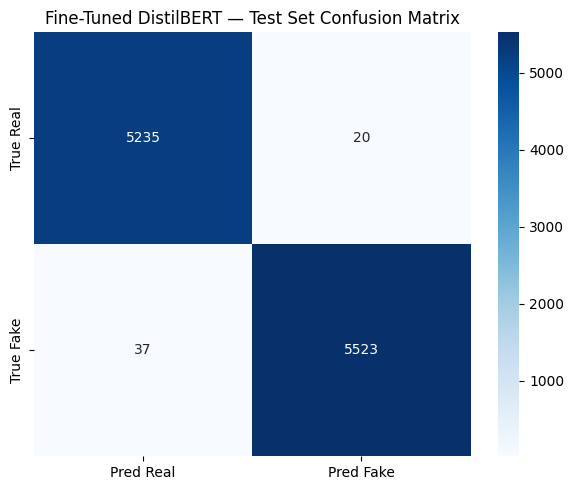

In [7]:
# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred Real', 'Pred Fake'],
            yticklabels=['True Real', 'True Fake'])
plt.title('Fine-Tuned DistilBERT — Test Set Confusion Matrix')
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'confusion_matrix.png'), dpi=150)
plt.show()

## 5. Error Analysis

In [8]:
error_mask = all_labels != all_preds
fp_mask    = (all_labels == 0) & (all_preds == 1)   # Real → predicted Fake
fn_mask    = (all_labels == 1) & (all_preds == 0)   # Fake → predicted Real

print(f"Total errors:    {error_mask.sum()} / {len(all_labels)} ({error_mask.mean():.1%})")
print(f"False Positives (Real → Fake): {fp_mask.sum()}")
print(f"False Negatives (Fake → Real): {fn_mask.sum()}")

print("\nSample False Positives (model thought Fake was Real):")
for text, prob in zip(X_test[fp_mask][:3], all_probs[fp_mask][:3]):
    print(f"  P(fake)={prob[1]:.3f}: {text[:120]}...\n")

print("Sample False Negatives (model thought Real was Fake):")
for text, prob in zip(X_test[fn_mask][:3], all_probs[fn_mask][:3]):
    print(f"  P(fake)={prob[1]:.3f}: {text[:120]}...\n")

Total errors:    57 / 10815 (0.5%)
False Positives (Real → Fake): 20
False Negatives (Fake → Real): 37

Sample False Positives (model thought Fake was Real):
  P(fake)=0.994: The Daily 202: Bill Clinton’s argument with Black Lives Matter protesters is 2016’s Sister Souljah Moment Bill Clinton s...

  P(fake)=1.000: Macedonia's parliament adopts 2018 budget, opposition boycotts vote SKOPJE - Macedonia s parliament has adopted a 2018 d...

  P(fake)=0.979: Donald Trump’s white fascist brigade: His rallies are now a safe space for racism At least a half-dozen attendees shoved...

Sample False Negatives (model thought Real was Fake):
  P(fake)=0.053: Democrat Electors Try To Persuade GOP Electors To Abandon Trump Democrats furious that Donald Trump won the presidency d...

  P(fake)=0.000: A Defeated Obama Condescendingly Mocks Winner Trump, Says ‘He Can’t Keep Campaign Promises’   A Defeated Obama Condescen...

  P(fake)=0.000:  Trump Threatens Public University Because Protesters Didn’t 

## 6. Probability Calibration Check

Checks whether P(fake)=0.8 actually means 80% of those articles are fake.
Good calibration matters for the ensemble — if probabilities are skewed,
they need temperature scaling before combining with the TF-IDF signal.

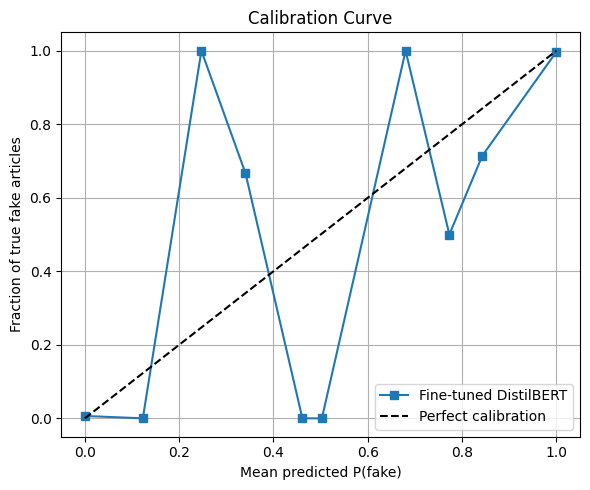

If the curve closely follows the diagonal, probabilities are well-calibrated.
If it deviates significantly, apply temperature scaling in the ensemble notebook.


In [9]:
fake_probs = all_probs[:, 1]

fraction_of_positives, mean_predicted_value = calibration_curve(
    y_test, fake_probs, n_bins=10
)

plt.figure(figsize=(6, 5))
plt.plot(mean_predicted_value, fraction_of_positives, 's-', label='Fine-tuned DistilBERT')
plt.plot([0, 1], [0, 1], 'k--', label='Perfect calibration')
plt.xlabel('Mean predicted P(fake)')
plt.ylabel('Fraction of true fake articles')
plt.title('Calibration Curve')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'calibration_curve.png'), dpi=150)
plt.show()

print("If the curve closely follows the diagonal, probabilities are well-calibrated.")
print("If it deviates significantly, apply temperature scaling in the ensemble notebook.")

## 7. Inference Utilities

These two functions are what the ensemble notebook will import and use.

In [10]:
def predict_article(title: str, text: str, model, tokenizer, device,
                    max_len: int = MAX_LEN) -> dict:
    """
    Classify a single news article.

    Returns
    -------
    dict with keys:
        prediction       : 'REAL' or 'FAKE'
        fake_probability : float in [0, 1]
        real_probability : float in [0, 1]
        confidence       : probability of the predicted class
    """
    content = (title + ' ' + text).strip()
    inputs  = tokenizer(
        content,
        max_length=max_len,
        padding='max_length',
        truncation=True,
        return_attention_mask=True,
        return_tensors='pt',
    )
    model.eval()
    with torch.no_grad():
        outputs = model(
            input_ids=inputs['input_ids'].to(device),
            attention_mask=inputs['attention_mask'].to(device),
        )
    probs    = torch.softmax(outputs.logits, dim=-1).squeeze().cpu().numpy()
    pred_idx = probs.argmax()

    return {
        'prediction':       'REAL' if pred_idx == 0 else 'FAKE',
        'fake_probability': float(probs[1]),
        'real_probability': float(probs[0]),
        'confidence':       float(probs[pred_idx]),
    }


def predict_batch(texts: list, model, tokenizer, device,
                  max_len: int = MAX_LEN, batch_size: int = 32) -> np.ndarray:
    """
    Batch inference over a list of strings.

    Returns
    -------
    probs : np.ndarray shape (n_samples, 2)
            Column 0 = P(real), Column 1 = P(fake)
    """
    model.eval()
    all_probs = []

    for i in tqdm(range(0, len(texts), batch_size), desc='Batch inference'):
        batch_texts = list(texts[i : i + batch_size])
        inputs = tokenizer(
            batch_texts,
            max_length=max_len,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt',
        )
        with torch.no_grad():
            outputs = model(
                input_ids=inputs['input_ids'].to(device),
                attention_mask=inputs['attention_mask'].to(device),
            )
        probs = torch.softmax(outputs.logits, dim=-1).cpu().numpy()
        all_probs.append(probs)

    return np.vstack(all_probs)


print("Inference functions defined: predict_article(), predict_batch()")

Inference functions defined: predict_article(), predict_batch()


In [11]:
# ── Smoke test ────────────────────────────────────────────────────────────────
test_cases = [
    ("Coronavirus, 100 days that changed the world",
     "A 7.2 magnitude earthquake struck the coast of Chile on Tuesday, "
     "causing widespread structural damage and triggering a tsunami warning."),

    ("You won't BELIEVE what they're hiding from you!!",
     "Deep state operatives have been caught red-handed orchestrating a massive "
     "cover-up that the mainstream media refuses to report."),

    ("Federal Reserve holds interest rates steady",
     "The Federal Reserve held interest rates unchanged at its meeting Wednesday, "
     "citing persistent inflation and a resilient labor market."),
]

print("Inference smoke test")
print("=" * 60)
for title, text in test_cases:
    result = predict_article(title, text, distilbert_model, tokenizer, device)
    print(f"Title     : {title[:70]}")
    print(f"Prediction: {result['prediction']}  "
          f"(fake_prob={result['fake_probability']:.3f}, "
          f"confidence={result['confidence']:.3f})")
    print()

Inference smoke test
Title     : Coronavirus, 100 days that changed the world
Prediction: REAL  (fake_prob=0.056, confidence=0.944)

Title     : You won't BELIEVE what they're hiding from you!!
Prediction: FAKE  (fake_prob=1.000, confidence=1.000)

Title     : Federal Reserve holds interest rates steady
Prediction: REAL  (fake_prob=0.000, confidence=1.000)



In [12]:
test_cases = [
    # Should be REAL — neutral, factual, attributed journalism
    ("Federal Reserve holds interest rates steady",
     "The Federal Reserve held interest rates unchanged at its meeting Wednesday, "
     "citing persistent inflation and a resilient labor market. Fed chair Jerome Powell "
     "said policymakers want to see further progress on inflation before cutting rates."),

    # Should be REAL — factual crisis reporting
    ("Coronavirus: WHO declares global pandemic as cases spread",
     "The World Health Organization has declared the coronavirus outbreak a global pandemic. "
     "Director-General Tedros Adhanom Ghebreyesus said the organisation was deeply concerned "
     "by alarming levels of spread and severity of the outbreak across 114 countries."),

    # Should be FAKE — sensationalist, conspiratorial, ALL CAPS
    ("You won't BELIEVE what they're hiding from you!!",
     "Deep state operatives have been caught red-handed orchestrating a massive "
     "cover-up that the mainstream media refuses to report. SHARE before they delete this. "
     "The truth is finally coming out and the elites are TERRIFIED."),

    # Should be FAKE — fake celebrity clickbait
    ("SHOCKING: Hollywood Legend Just Died Of Terrible Disease",
     "Hollywood loses yet another one of their dearest stars. We are absolutely heartbroken "
     "to hear about this tragedy. You won't believe who it was — click to find out the truth "
     "they don't want you to know."),

    # Edge case — crisis topic but written in legitimate journalistic style
    ("Ukraine conflict: latest updates from the front line",
     "Ukrainian forces reported advances in the Kherson region on Thursday according to "
     "military officials. The United Nations warned of a growing humanitarian crisis "
     "as winter approaches, with millions displaced from their homes."),
]

print("Inference smoke test")
print("=" * 60)
for title, text in test_cases:
    result = predict_article(title, text, distilbert_model, tokenizer, device)
    print(f"Title     : {title[:70]}")
    print(f"Prediction: {result['prediction']}  "
          f"(fake_prob={result['fake_probability']:.3f}, "
          f"confidence={result['confidence']:.3f})")
    print()

Inference smoke test
Title     : Federal Reserve holds interest rates steady
Prediction: REAL  (fake_prob=0.000, confidence=1.000)

Title     : Coronavirus: WHO declares global pandemic as cases spread
Prediction: REAL  (fake_prob=0.000, confidence=1.000)

Title     : You won't BELIEVE what they're hiding from you!!
Prediction: FAKE  (fake_prob=1.000, confidence=1.000)

Title     : SHOCKING: Hollywood Legend Just Died Of Terrible Disease
Prediction: FAKE  (fake_prob=1.000, confidence=1.000)

Title     : Ukraine conflict: latest updates from the front line
Prediction: REAL  (fake_prob=0.001, confidence=0.999)



## 8. How to Load in the Ensemble Notebook

Copy this block into the ensemble notebook to get the model and inference
functions ready in one go.

In [13]:
# ─── Ensemble notebook boilerplate (reference — do not run here) ──────────────
#
# import torch, numpy as np
# from transformers import DistilBertTokenizerFast, DistilBertForSequenceClassification
# from tqdm.auto import tqdm
#
# SAVE_DIR = './distilbert_finetuned'
# MAX_LEN  = 256
# device   = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
#
# tokenizer        = DistilBertTokenizerFast.from_pretrained(SAVE_DIR)
# distilbert_model = DistilBertForSequenceClassification.from_pretrained(SAVE_DIR)
# distilbert_model = distilbert_model.to(device)
# distilbert_model.eval()
#
# # Then use predict_batch(texts, distilbert_model, tokenizer, device)
# # Returns (n, 2) array — column 0 = P(real), column 1 = P(fake)

print("Model is ready for use in the ensemble notebook.")
print(f"Saved at: {os.path.abspath(SAVE_DIR)}")

Model is ready for use in the ensemble notebook.
Saved at: /content/drive/MyDrive/Colab Notebooks/Thesis Notebooks and Data/distilbert_finetuned


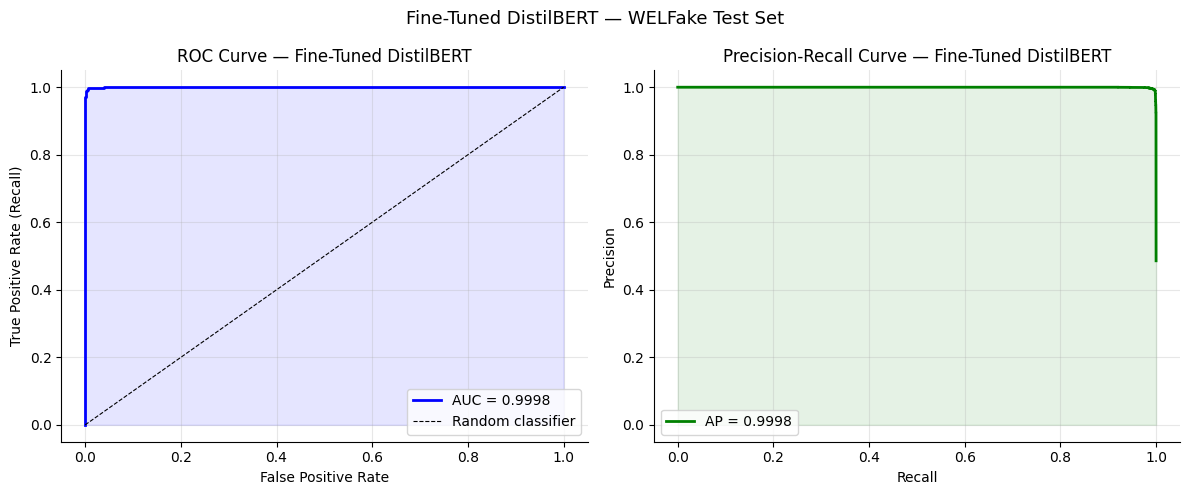

ROC AUC:              0.9998
Average Precision:    0.9998

Optimal threshold (Youden's J): 0.197
  TPR at optimal: 0.9968
  FPR at optimal: 0.0070


In [14]:
from sklearn.metrics import roc_curve, precision_recall_curve, auc

fake_probs = all_probs[:, 0]  # class 0 = fake

# ROC curve
fpr, tpr, roc_thresholds = roc_curve(all_labels, fake_probs, pos_label=0)
roc_auc = auc(fpr, tpr)

# Precision-Recall curve
precision, recall, pr_thresholds = precision_recall_curve(all_labels, fake_probs, pos_label=0)
pr_auc = auc(recall, precision)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ROC
axes[0].plot(fpr, tpr, 'b-', linewidth=2, label=f'AUC = {roc_auc:.4f}')
axes[0].plot([0, 1], [0, 1], 'k--', linewidth=0.8, label='Random classifier')
axes[0].fill_between(fpr, tpr, alpha=0.1, color='blue')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate (Recall)')
axes[0].set_title('ROC Curve — Fine-Tuned DistilBERT')
axes[0].legend(loc='lower right')
axes[0].grid(True, alpha=0.3)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Precision-Recall
axes[1].plot(recall, precision, 'g-', linewidth=2, label=f'AP = {pr_auc:.4f}')
axes[1].fill_between(recall, precision, alpha=0.1, color='green')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve — Fine-Tuned DistilBERT')
axes[1].legend(loc='lower left')
axes[1].grid(True, alpha=0.3)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.suptitle('Fine-Tuned DistilBERT — WELFake Test Set', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'roc_pr_curves.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"ROC AUC:              {roc_auc:.4f}")
print(f"Average Precision:    {pr_auc:.4f}")

# Optimal threshold by Youden's J statistic (maximises TPR - FPR)
j_scores   = tpr - fpr
optimal_idx = j_scores.argmax()
optimal_threshold = roc_thresholds[optimal_idx]
print(f"\nOptimal threshold (Youden's J): {optimal_threshold:.3f}")
print(f"  TPR at optimal: {tpr[optimal_idx]:.4f}")
print(f"  FPR at optimal: {fpr[optimal_idx]:.4f}")